# 02 - The Leaky Pipeline

This notebook reproduces the mistake described in *"A Dark Side of Cancer
Computing"*, section 4.2 ("Doubling the dataset"):

1. **Duplicate** the dataset (every row copied once).
2. **Then** split into train/test.

Because duplication happens before the split, exact copies of rows can end
up on both sides of the split - the model gets tested on data it has
effectively already memorised. Watch the "best case" (max) accuracy
numbers below - some models reach **100%**.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from cancer_ml_leakage_demo.data import load_data
from cancer_ml_leakage_demo.leakage import leaky_split
from cancer_ml_leakage_demo.metrics import run_experiment, summarize

X, y = load_data()

## Run The Experiment
Same as the paper: try every split ratio (50-50, 60-40, 70-30, 80-20),
repeat each one 100 times with a different random split, and record every
model's accuracy each time.

In [2]:
SPLIT_RATIOS = {
    "50-50": 0.5,
    "60-40": 0.4,
    "70-30": 0.3,
    "80-20": 0.2,
}
N_ROUNDS = 100

leaky_summaries = []
for split_name, test_size in SPLIT_RATIOS.items():
    results = run_experiment(X, y, split_fn = leaky_split, test_size = test_size, n_rounds = N_ROUNDS)
    summary = summarize(results)
    summary.insert(0, "split", split_name)
    leaky_summaries.append(summary)
    print(f"done: {split_name} split")

leaky_summary = pd.concat(leaky_summaries, ignore_index=True)
leaky_summary

done: 50-50 split
done: 60-40 split
done: 70-30 split


R:\My Projects\cancer_ml_leakage_demo\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


done: 80-20 split


,split,model,mean_accuracy,max_accuracy,min_accuracy
0,50-50,Random Forest,0.980457,0.992970,0.957821
1,50-50,Decision Tree,0.966081,0.985940,0.936731
2,50-50,Logistic Regression,0.956591,0.975395,0.940246
3,50-50,Neural Network,0.941424,0.966608,0.913884
4,50-50,Naive Bayes,0.939543,0.954306,0.908612
5,50-50,Nearest Neighbor,0.934394,0.954306,0.901582
6,50-50,SVM,0.919033,0.934974,0.898067
7,60-40,Random Forest,0.985614,1.000000,0.956140
8,60-40,Decision Tree,0.972807,0.991228,0.947368
9,60-40,Logistic Regression,0.957500,0.978070,0.938596


## Save The Results
Saved so `max_vs_min_accuracy.ipynb` can load it back in and compare against the correct pipeline.

In [3]:
leaky_summary.to_csv("../results/tables/leaky_summary.csv", index=False)
print("saved to results/tables/leaky_summary.csv")

saved to results/tables/leaky_summary.csv


## How Many Models Hit 100% Accuracy?

In [4]:
perfect = leaky_summary[leaky_summary["max_accuracy"] >= 0.999]
print(f"{len(perfect)} (split, model) combinations reached ~100% best-case accuracy:\n")
perfect[["split", "model", "max_accuracy"]]

5 (split, model) combinations reached ~100% best-case accuracy:



,split,model,max_accuracy
7,60-40,Random Forest,1.0
14,70-30,Random Forest,1.0
15,70-30,Decision Tree,1.0
21,80-20,Random Forest,1.0
22,80-20,Decision Tree,1.0


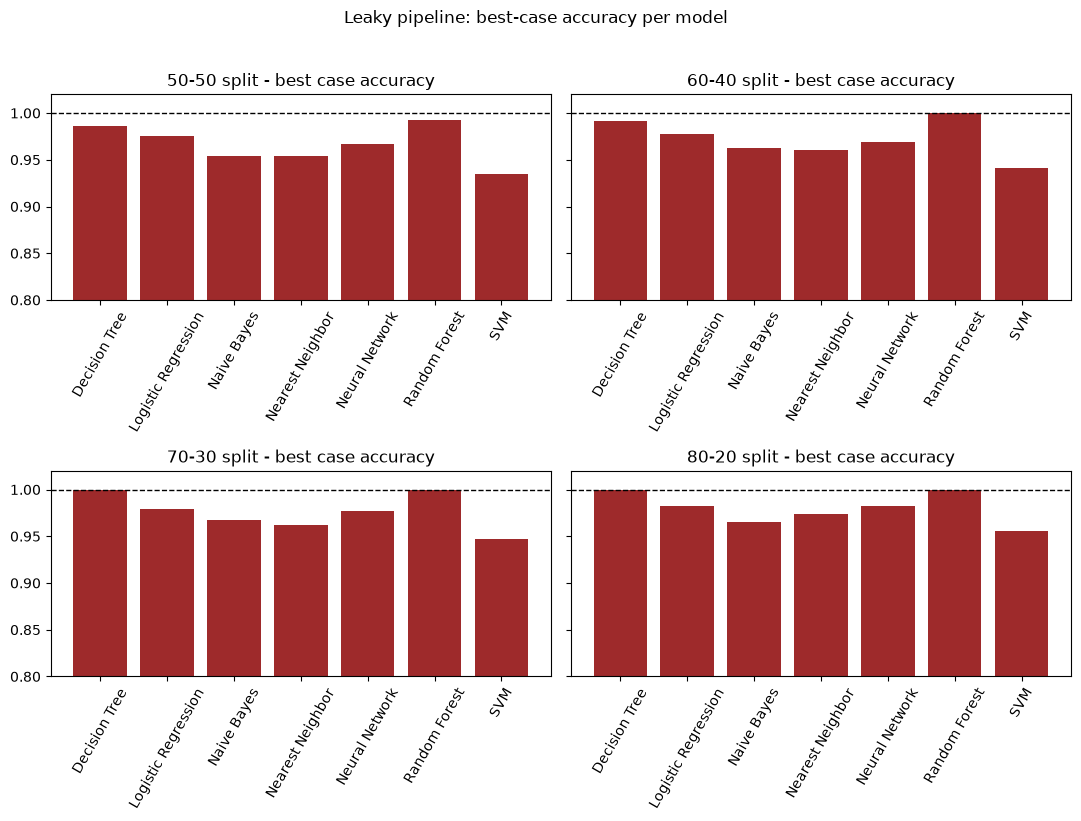

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)

for ax, (split_name, _) in zip(axes.flat, SPLIT_RATIOS.items()):
    subset = leaky_summary[leaky_summary["split"] == split_name].sort_values("model")
    ax.bar(subset["model"], subset["max_accuracy"], color="#9E2A2B")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{split_name} split - best case accuracy")
    ax.set_ylim(0.8, 1.02)
    ax.tick_params(axis="x", rotation=60)

fig.suptitle("Leaky pipeline: best-case accuracy per model", y=1.02)
fig.tight_layout()
fig.savefig("../results/figures/02_leaky_max_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## Observation
Several models usually Random Forest and Decision Tree, sometimes Neural
Network reach 100% best-case accuracy. That is not a well-trained model:
it is a model that got lucky on which duplicate rows ended up in its test
set.

Next: `03_correct_pipeline.ipynb` runs the exact same experiment with the
leakage fixed, for comparison.